<a href="https://colab.research.google.com/github/aialetheiaworks/Choice-forge/blob/main/IP_Project_Question_Notebook_KartikayMalhotra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

Write the problem statement and objectives here


### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [53]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np

### Understanding the structure of the data

In [54]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

### Upload the FoodHub order dataset from the local computer
from google.colab import files
uploaded = files.upload()

Saving foodhub_order.csv to foodhub_order (1).csv


In [55]:
# Write your code here to read the data
#df = pd.read_csv("foodhub_order.csv")
filename = list(uploaded.keys())[0]
print(filename)
df = pd.read_csv(filename)


foodhub_order (1).csv


In [56]:
# Write your code here to view the first 5 rows
df.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [57]:
# Write your code here
rows = df.shape[0]
columns = df.shape[1]
print("Number of rows   :", rows)
print("Number of columns:", columns)

Number of rows   : 1898
Number of columns: 9


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [58]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [59]:
# Write your code here
# Check for missing values in dataframe
missing_values = df.isnull().sum()

# In percentage
missing_percentage = (missing_values / len(df)) * 100


#print("\n\nPercentage of missing values:")
#print(missing_percentage.round(2))

#print("Missing values in each column:", "Percentage of missing values:")
#print(missing_values, missing_percentage.round(2))

#print("Missing values:", missing_values, "| Missing percentage:", missing_percentage.round(2))

# Create a new table to display the results
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2).astype(str) + "%"
})

display(missing_summary)


,Missing Values,Missing Percentage (%)
order_id,0,0.0%
customer_id,0,0.0%
restaurant_name,0,0.0%
cuisine_type,0,0.0%
cost_of_the_order,0,0.0%
day_of_the_week,0,0.0%
rating,0,0.0%
food_preparation_time,0,0.0%
delivery_time,0,0.0%


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [60]:
# Write your code here
# Display the statistical summary
summary = df.describe()

#Using display() method of Jupiter Notebook & Google Colab
print("Statistical Summary:")
display(summary)

summ_food_prep_time = df['food_preparation_time'].describe()

print("\n\nStatistical Summary of food preparation time:")
display(summ_food_prep_time)

FP_min_time = df["food_preparation_time"].min()
FP_avg_time = df["food_preparation_time"].mean()
FP_max_time = df["food_preparation_time"].max()

print("Food Preparation Time:")
print("Minimum time:", FP_min_time, "minutes")
#print("Average time:", FP_avg_time, "minutes")
print("Average time:", round(FP_avg_time, 2), "minutes")
print("Maximum time:", FP_max_time, "minutes")

Statistical Summary:


,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000




Statistical Summary of food preparation time:


,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


Food Preparation Time:
Minimum time: 20 minutes
Average time: 27.37 minutes
Maximum time: 35 minutes


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [61]:
# Write the code here
#736/1898
not_rated_orders = (df["rating"] == "Not given").sum()

print("Orders not rated:", not_rated_orders, "/", f"{len(df):,}", end=" = ") # f"{1898:,}" to inset commas
print(ro:=round(not_rated_orders / len(df) * 100,2), "%") #assignment expression :=
print("Rated orders:", round(100-ro,2), "%") #Saved repeated computation by assignment expression above :)


Orders not rated: 736 / 1,898 = 38.78 %
Rated orders: 61.22 %


#### Observations:


### Exploratory Data Analysis (EDA)

*   List item
*   List item



# Univariate Analysis
##### Is there an observable relationship between rating and X?

For example:

**Variable (X)** - Question
**Total time** - Does longer total time relate to lower ratings?

**Preparation time** - Does longer preparation relate to lower ratings?

**Delivery time**	- Does longer delivery relate to lower ratings?

**Cost** - Does order cost relate to rating?

**Cuisine**	- Do ratings differ by cuisine?

**Restaurant** - Do ratings differ by restaurant?

**Day** - Do ratings differ by day?

**Time of day** - Do ratings differ by ordering period?

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

,Variable,Unique values
0,Total Orders,1898
1,Unique Customers,1200
2,Unique Restaurants,178
3,Unique Cuisines,14


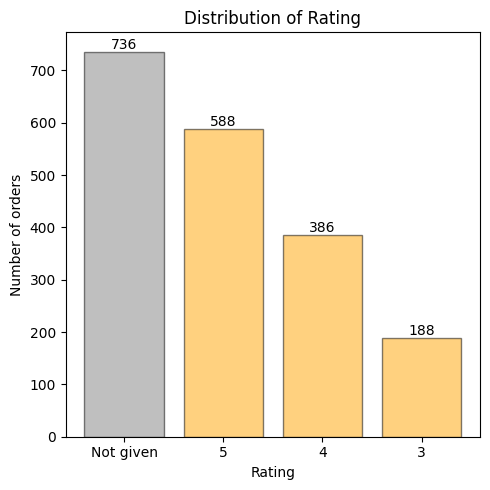

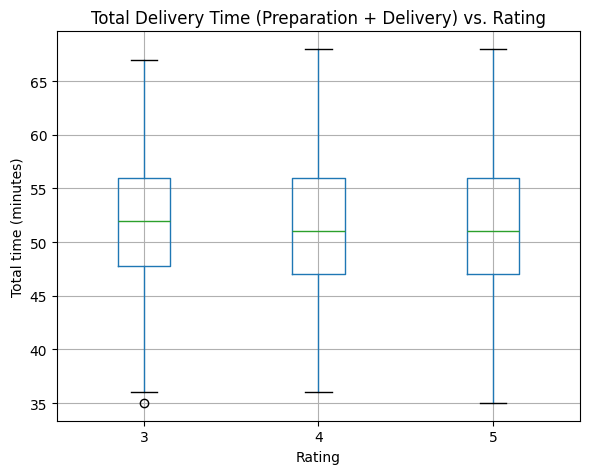

In [62]:
# Write the code here
##print(df.head(5))
# Identifier variables: inspect uniqueness of IDs
id_summary = pd.DataFrame({
    "Variable": ["Total Orders", "Unique Customers", "Unique Restaurants", "Unique Cuisines"],
    "Unique values": [
        df["order_id"].nunique(),
        df["customer_id"].nunique(), #1,898 orders came from 1,200 different customers
        df["restaurant_name"].nunique(),
        df['cuisine_type'].nunique()],

})
display(id_summary)

import matplotlib.pyplot as plt


print("\n\n")

#Display Ratings
fig, ax = plt.subplots(figsize=(5, 5))
rating_counts = df["rating"].value_counts()

colors = ["orange"] * len(rating_counts)
colors[list(rating_counts.index).index("Not given")] = "gray"

# ax.bar(x, height, optional: color, edgecolor, transparency)
ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="black", alpha=0.5)

ax.set_title("Distribution of Rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of orders")
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()


print("\n\n")

#Overall Delivery Time vs. Rating
#display(df)

rated_df = df[df["rating"] != "Not given"].copy()
rated_df["rating"] = rated_df["rating"].astype(int)

rated_df["total_time"] = (
    rated_df["food_preparation_time"] + rated_df["delivery_time"]
)

#display(rated_df)
fig, ax = plt.subplots(figsize=(6, 5))

rated_df.boxplot(
    column="total_time",
    by="rating",
    ax=ax
)

ax.set_title("Total Delivery Time (Preparation + Delivery) vs. Rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Total time (minutes)")

plt.suptitle("")   # removes pandas' automatic title
plt.tight_layout()
plt.show()



### *Total delivery time appears to have **little or no visible relationship with customer ratings,** as the distributions of total delivery time are very similar across ratings 3, 4, and 5.*

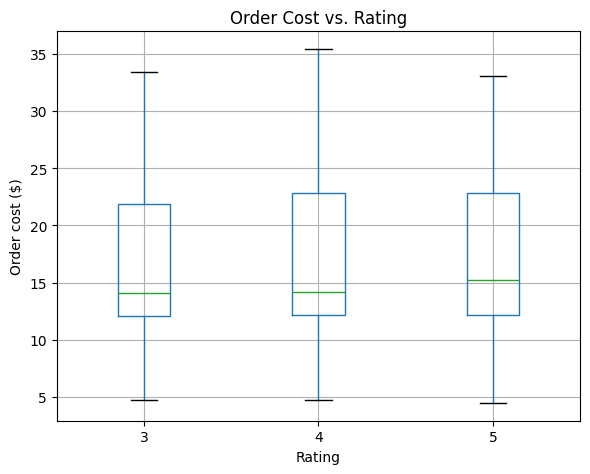

In [63]:
#Order Cost  vs. rating
fig, ax = plt.subplots(figsize=(6, 5))

rated_df.boxplot(column="cost_of_the_order", by="rating", ax=ax)

ax.set_title("Order Cost vs. Rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Order cost ($)")

plt.suptitle("")
plt.tight_layout()
plt.show()

###*Order cost does not show a strong visible relationship with rating. Therefore, future-order satisfaction is likely to need other operational or customer-experience variables rather than simply price/value of the order.*

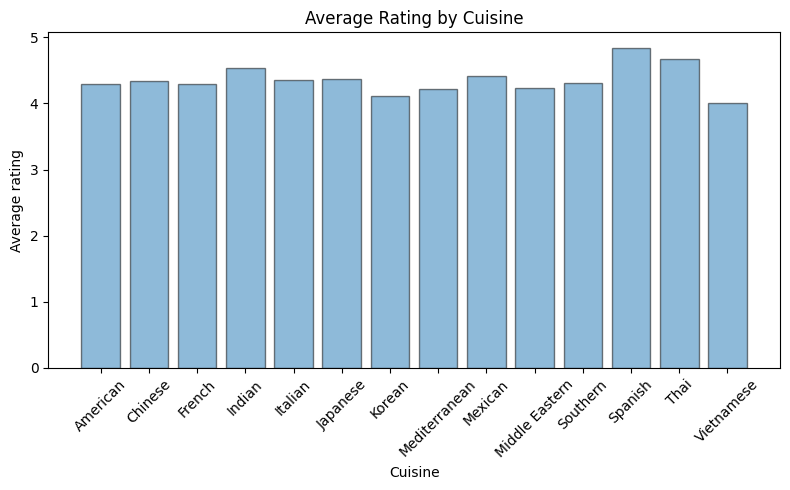

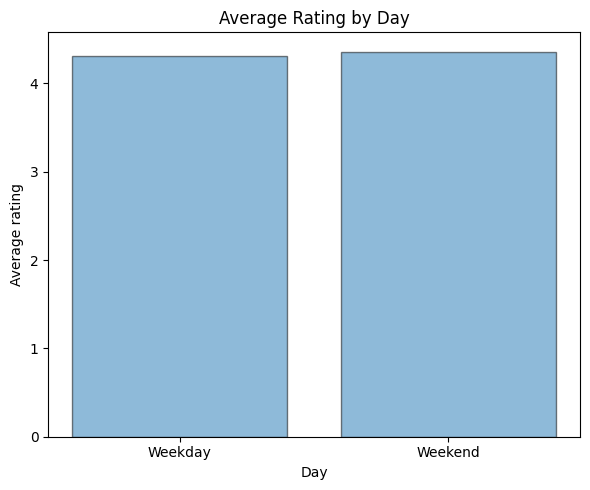

In [64]:
###Cuisine vs Rating
cuisine_rating = rated_df.groupby("cuisine_type")["rating"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(cuisine_rating.index, cuisine_rating.values,
       edgecolor="black", alpha=0.5)

ax.set_title("Average Rating by Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Average rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n\n")
###Day of the week vs Rating
day_rating = rated_df.groupby("day_of_the_week")["rating"].mean()

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(day_rating.index, day_rating.values,
       edgecolor="black", alpha=0.5)

ax.set_title("Average Rating by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Average rating")

plt.tight_layout()
plt.show()


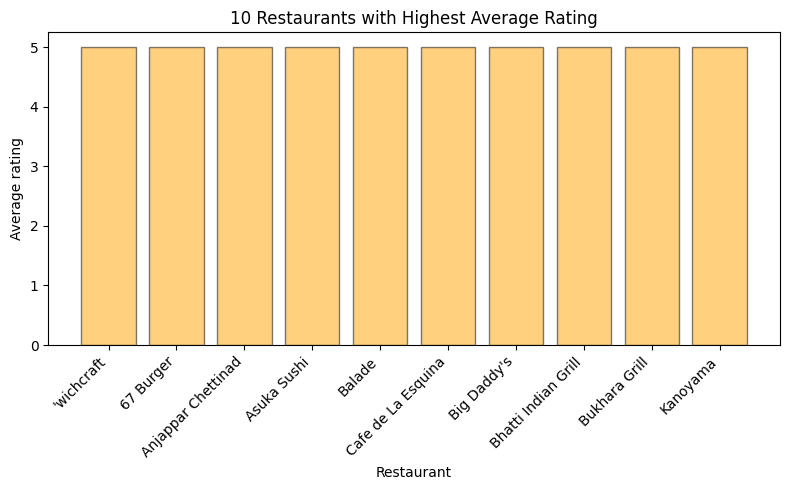

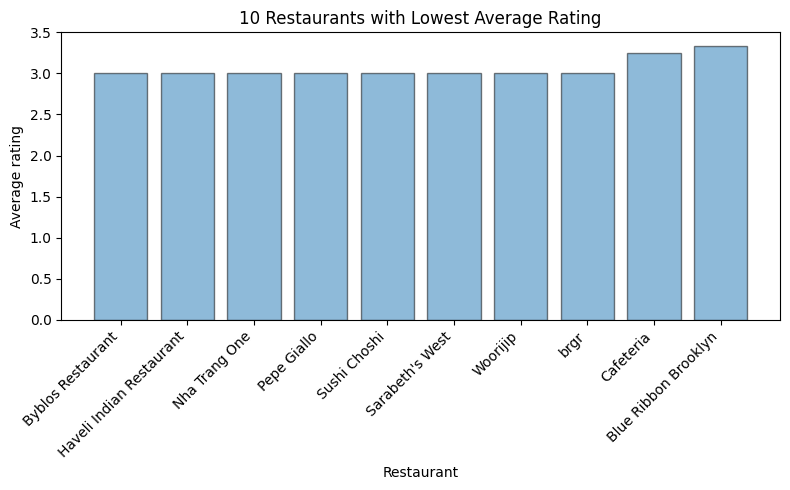

In [65]:
###Restaurant vs Rating
    # restaurant_rating = rated_df.groupby("restaurant_name")["rating"].mean()

    # fig, ax = plt.subplots(figsize=(10, 5))

    # ax.bar(restaurant_rating.index, restaurant_rating.values, edgecolor="black", alpha=0.5, bins=20)

    # ax.set_title("Average Rating by Restaurant")
    # ax.set_xlabel("Restaurant")
    # ax.set_ylabel("Average rating")

    # plt.xticks(rotation=90)
    # plt.tight_layout()
    # plt.show()

### Restaurant vs Rating

restaurant_rating = (
    rated_df.groupby("restaurant_name")["rating"]
    .mean()
)

# 10 highest-rated restaurants
highest_rated = restaurant_rating.sort_values(ascending=False).head(10)

# 10 lowest-rated restaurants
lowest_rated = restaurant_rating.sort_values().head(10)


# Plot highest-rated restaurants
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    highest_rated.index,
    highest_rated.values,
    color = "orange",
    edgecolor="black",
    alpha=0.5
)

ax.set_title("10 Restaurants with Highest Average Rating")
ax.set_xlabel("Restaurant")
ax.set_ylabel("Average rating")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n\n")
# Plot lowest-rated restaurants
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    lowest_rated.index,
    lowest_rated.values,
    edgecolor="black",
    alpha=0.5
)

ax.set_title("10 Restaurants with Lowest Average Rating")
ax.set_xlabel("Restaurant")
ax.set_ylabel("Average rating")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




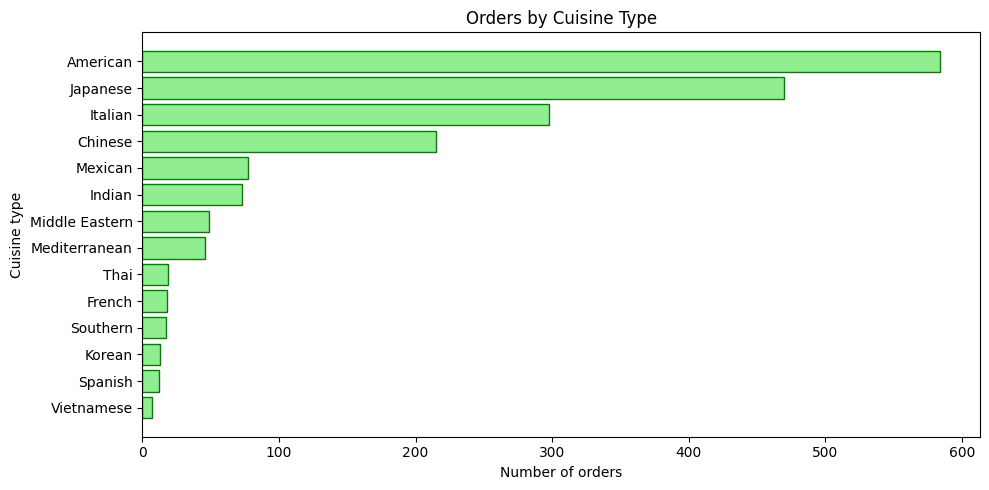

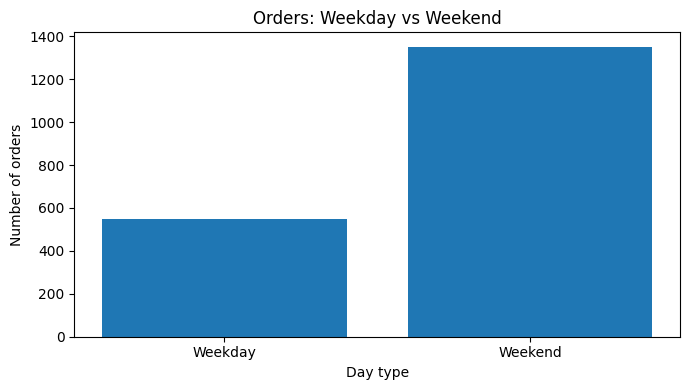

In [66]:
#display(df.head(5))

# Cuisine distribution
cuisine_counts = df["cuisine_type"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cuisine_counts.index, cuisine_counts.values, color="lightgreen", edgecolor="green")
ax.set_title("Orders by Cuisine Type")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Cuisine type")
plt.tight_layout()
plt.show()

print("\n\n")
# Day-of-week distribution
day_counts = df["day_of_the_week"].value_counts().reindex(["Weekday", "Weekend"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(day_counts.index, day_counts.values)
ax.set_title("Orders: Weekday vs Weekend")
ax.set_xlabel("Day type")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [104]:
# Write the code here

#value_counts() counts how many times each unique value appears in a column, "restaurant_name"
top5_restaurants = df["restaurant_name"].value_counts().head(5).reset_index()
top5_restaurants.columns = ["restaurant_name", "order_count"]

#Index must begin with count 1
#top5_restaurants.index = top5_restaurants.index + 1

top5_restaurants.insert(0, "S.No.", range(1, 6))

#display(top5_restaurants)
display(top5_restaurants.style.hide(axis="index"))

# Total orders from top 5 restaurants
top5_orders = top5_restaurants["order_count"].sum()
top5_percentage = top5_orders / len(df) * 100
print(f"\n\n\033[1mTop 5 restaurants: {top5_orders:,} orders ({top5_percentage:.2f}% of all orders)\033[0m")


S.No.,restaurant_name,order_count
1,Shake Shack,219
2,The Meatball Shop,132
3,Blue Ribbon Sushi,119
4,Blue Ribbon Fried Chicken,96
5,Parm,68




Top 5 restaurants: 634 orders (33.40% of all orders)


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [68]:
# Write the code here

#Get weekend orders
#Step 1: Find the Weekend rows
#display(df.head(5))
weekend_rows = df["day_of_the_week"] == "Weekend"
#print(weekend_rows)

#Step 2: Keep only those rows
weekend = df[weekend_rows]
#print(weekend)

#Get the cuisine types
cuisines = weekend["cuisine_type"]
#print(cuisines)

#Count each cuisine
weekend_cuisine = cuisines.value_counts()

#Show the top 10
display(weekend_cuisine.head())

#Show the most popular cuisine
print(
    f"Most popular weekend cuisine: {weekend_cuisine.index[0]} "
    f"({weekend_cuisine.iloc[0]} orders)"
)


,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


Most popular weekend cuisine: American (415 orders)


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [69]:
# Write the code here
orders_over20 = (df["cost_of_the_order"] > 20).sum()
percentage_over20 = orders_over20 / len(df) * 100
print(f"Orders costing more than $20: {orders_over20:,}")
#print(f"Percentage of orders costing more than $20:", round(percentage_over20,2),"%")
#print(f"Percentage of orders costing more than $20:", str(round(percentage_over20,2))+"%")
print(f"Percentage of orders costing more than $20: {percentage_over20:.2f}%")

Orders costing more than $20: 555
Percentage of orders costing more than $20: 29.24%


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [70]:
# Write the code here
mean_delivery_time = df["delivery_time"].mean()
print(f"Mean delivery time: {mean_delivery_time:.2f} minutes")

Mean delivery time: 24.16 minutes


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [71]:
# Write the code here

# Count orders for each customer and take the top 3
top3_customers = df["customer_id"].value_counts().head(3)

# Display the result
display(top3_customers)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


,cost_of_the_order,food_preparation_time,delivery_time,total_time
cost_of_the_order,1.000000,0.041527,-0.029949,0.006358
food_preparation_time,0.041527,1.000000,0.011094,0.685970
delivery_time,-0.029949,0.011094,1.000000,0.735195
total_time,0.006358,0.685970,0.735195,1.000000




)


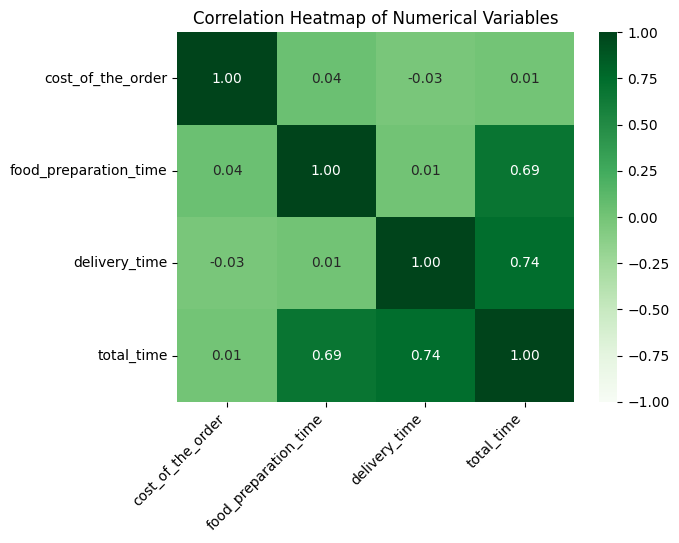

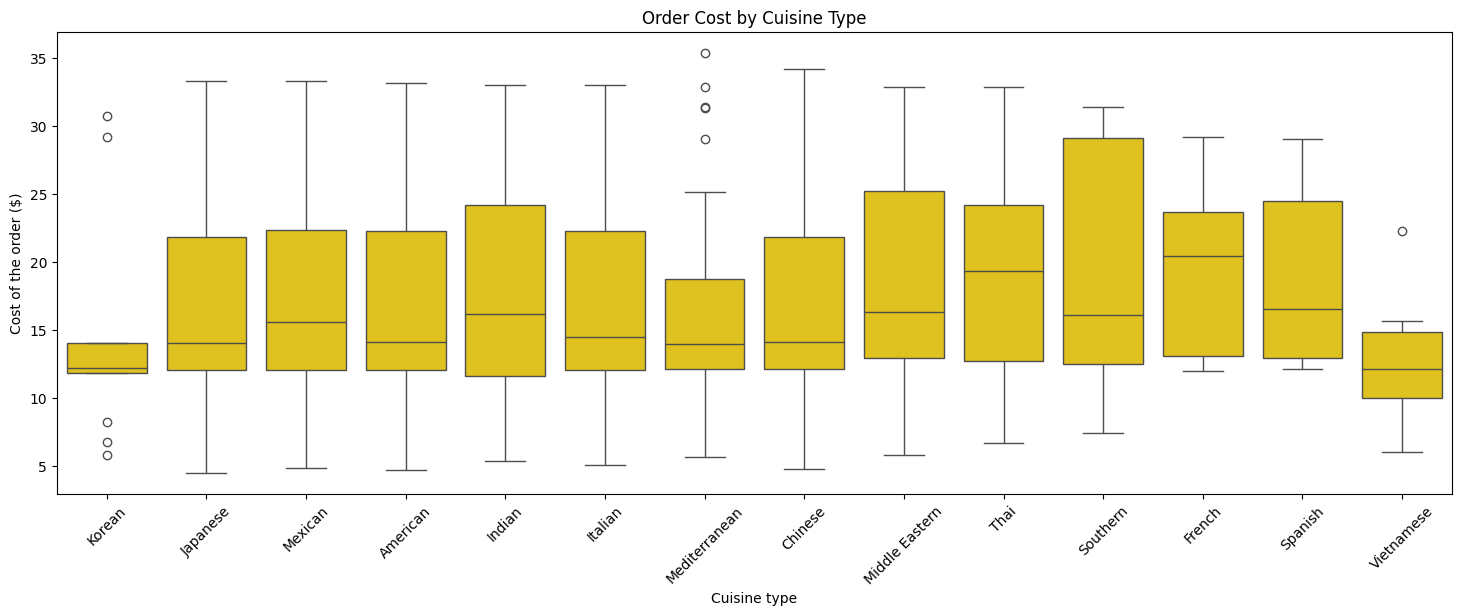

In [72]:
# Write the code here

#display(df.head())
df_multivariate = df.copy()

# Convert valid ratings to numeric; "Not given" becomes NaN.
df_multivariate["rating_numeric"] = pd.to_numeric(df_multivariate["rating"], errors="coerce")


# Total fulfilment time = preparation + delivery.
df_multivariate["total_time"] = df_multivariate["food_preparation_time"] + df_multivariate["delivery_time"]
#display(df_multivariate.head())

# 1. Correlation among numerical variables
numeric_cols = ["cost_of_the_order", "food_preparation_time", "delivery_time", "total_time"]
corr = df_multivariate[numeric_cols].corr()

display(corr)

import seaborn as sns
#import matplotlib.pyplot as plt

print("\n\n)")
sns.heatmap(corr, annot=True, cmap="Greens", vmin=-1, vmax=1, fmt=".2f")
#corr → correlation table
#annot=True → shows the correlation numbers
#fmt=".2f" → shows 2 decimal places
#cmap="Blues" → uses the blue color scale
#vmin=-1, vmax=1 → keeps the correlation scale from −1 to +1

plt.xticks(rotation=45, ha="right")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


###Cost vs. Cusine###

print("\n\n")
# Median order cost by cuisine
plt.figure(figsize=(18, 6)) #to make the graph more wider

# Boxplot
sns.boxplot(
    data=df_multivariate,
    x="cuisine_type",
    y="cost_of_the_order",
    showfliers=True,
    color="gold"
)

plt.title("Order Cost by Cuisine Type")
plt.xlabel("Cuisine type")
plt.ylabel("Cost of the order ($)")
plt.xticks(rotation=45)
plt.show()





###1. In this dataset, **more expensive orders do not appear to take meaningfully longer or shorter to prepare or deliver**. From a business perspective, this suggests that order value & service time are largely independent.
###===
###2. Cuisines such as **French**, **Thai** have relatively high median order costs, while **Korean** and **Vietnamese** have lower median order costs
###3. **Southern** shows substantial variation in order value. That suggests customers ordering these cuisines are not all spending around the same amount.

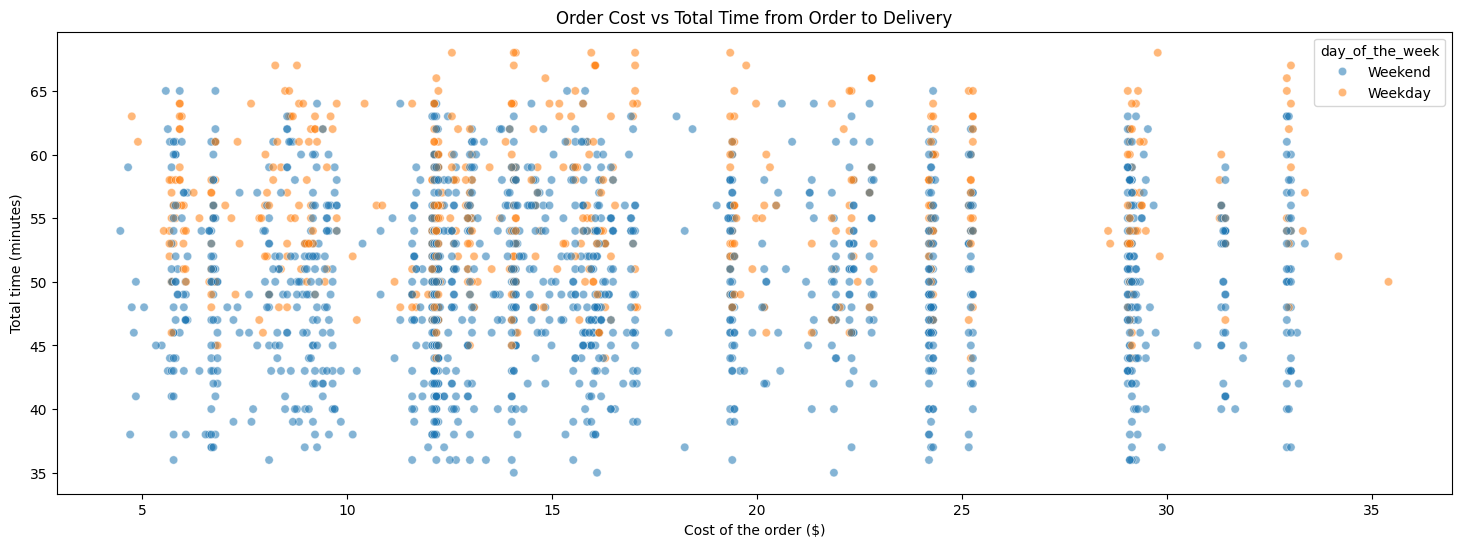

,orders,avg_cost,avg_preparation_time,avg_delivery_time,avg_total_time,avg_rating
day_of_the_week,,,,,,
Weekday,547,16.31,27.21,28.34,55.55,4.31
Weekend,1351,16.57,27.44,22.47,49.91,4.36


In [73]:
#Order cost versus total fulfilment time
# Order cost vs total fulfilment time

plt.figure(figsize=(18, 6)) #to make the graph more wider

sns.scatterplot(
    data=df_multivariate,
    x="cost_of_the_order",
    y="total_time",
    hue="day_of_the_week",
    alpha=0.55
)

plt.title("Order Cost vs Total Time from Order to Delivery")
plt.xlabel("Cost of the order ($)")
plt.ylabel("Total time (minutes)")
plt.show()


# Day-type comparison
day_summary = df_multivariate.groupby("day_of_the_week").agg({
    "order_id": "count",
    "cost_of_the_order": "mean",
    "food_preparation_time": "mean",
    "delivery_time": "mean",
    "total_time": "mean",
    "rating_numeric": "mean"
})

day_summary.columns = [
    "orders",
    "avg_cost",
    "avg_preparation_time",
    "avg_delivery_time",
    "avg_total_time",
    "avg_rating"
]

day_summary = day_summary.reindex(["Weekday", "Weekend"])

display(day_summary.round(2))

###**Weekend business is much larger**
###The volume of orders: 1,351 weekend orders versus 547 weekday orders (Weekend orders are ~2.3 time Weekday orders), yet the average order value is almost identical: 16.31 for weekdays vs. 16.57 weekend.

###A reasonable business hypothesis would be that weekday delivery faces more friction — perhaps traffic, demand patterns, or courier availability — but the graph itself cannot tell us why. A reasonable hypothesis could be:
#### a. Traffic is less on Weekends
#### b. The FoodHub employs more delivery staff

###**Weekend demand is substantially higher, with almost the same average order value, yet orders are fulfilled faster overall. The improvement comes primarily from shorter delivery times rather than faster food preparation.**

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [74]:
# Write the code here


#Remove unrated orders → calculate restaurant ratings → keep well-rated
#restaurants with enough ratings.

# 1. Keep only rated orders - Done above
#rated_df = df[df["rating"] != "Not given"].copy()
#rated_df["rating"] = pd.to_numeric(rated_df["rating"])

#2. Calculate number of ratings and average rating for each restaurant
restaurant_rating_summary = rated_df.groupby("restaurant_name")["rating"].agg(
    rating_count="count",
    average_rating="mean"
)

#display(restaurant_rating_summary.round(2).iloc[10:20])

#3. Find restaurants with more than 50 ratings and rating above 4
promotional_restaurants = restaurant_rating_summary[
    (restaurant_rating_summary["rating_count"] > 50) &
    (restaurant_rating_summary["average_rating"] > 4)
]

display(promotional_restaurants.round(2).sort_values("average_rating", ascending=False))




,rating_count,average_rating
restaurant_name,,
The Meatball Shop,84,4.51
Blue Ribbon Fried Chicken,64,4.33
Shake Shack,133,4.28
Blue Ribbon Sushi,73,4.22


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [116]:
# Write the code here

# Question 14 uses surcharge revenue only.
# Cost > $20            -> 25% surcharge
# $5 < Cost <= $20      -> 15% surcharge
# Therefore, Cost <= $5 -> no surcharge
#
# The underlying order value is NOT added to company revenue, that is, GMV
# (Gross Merchandise Value) would be the total value of all food orders placed
# through FoodHub, and is not calculated

fee_high = 25 / 100
fee_medium = 15 / 100

df["company_revenue"] = np.select(
    [
        df["cost_of_the_order"] > 20,
        df["cost_of_the_order"] > 5
    ],
    [
        df["cost_of_the_order"] * fee_high,   #25% is not accepted syntax
        df["cost_of_the_order"] * fee_medium  #15% is not accepted syntax
    ],
    default=0.0 #for cost <= $5
)

df["cost_band"] = pd.cut(
    df["cost_of_the_order"],
    bins=[-np.inf, 5, 20, np.inf],
    labels=["<= $5", "$5-$20", "> $20"]
)

revenue_by_band = (
    df.groupby("cost_band", observed=True)
      .agg(
          orders=("order_id", "count"),
          surcharge_revenue=("company_revenue", "sum")
      )
)
revenue_by_band["revenue_share_%"] = (
    revenue_by_band["surcharge_revenue"] / df["company_revenue"].sum() * 100
)

# revenue_by_band["orders_%"] = (
#     revenue_by_band["orders"] / df["orders"].sum() * 100
# )

# Percentage of total orders
revenue_by_band["orders_%"] = (
    revenue_by_band["orders"] / revenue_by_band["orders"].sum() * 100
)

#Set the order: orders → orders_% → surcharge_revenue → revenue_share_%
revenue_by_band = revenue_by_band[
    ["orders", "orders_%", "surcharge_revenue", "revenue_share_%"]
]

#display(revenue_by_band.round(2))
display(
    revenue_by_band.style.format({
        "orders": "{:,.0f}",
        "orders_%": "{:,.2f}%",
        "surcharge_revenue": "{:,.2f}",
        "revenue_share_%": "{:,.2f}%"
    })
)


net_revenue = df["company_revenue"].sum()
print(f"\nNet revenue generated by the company from surcharges: ${net_revenue:,.2f}")

avg_order_5_20 = df.loc[
    df["cost_band"] == "$5-$20",
    "cost_of_the_order"
].mean()

print(f"Average order value between $5 and $20: \033[1m${avg_order_5_20:.2f}\033[0m")

###########

# 1. Find customers who have at least one order between $17.50 and $20
customers = df.loc[
    (df["cost_of_the_order"] >= 17.5) &
    (df["cost_of_the_order"] <= 20),
    "customer_id"
].unique()

# 2. Get ALL orders placed by those customers
customer_orders = df[df["customer_id"].isin(customers)]

# 3. Number of unique customers
customer_count = len(customers)

# 4. Percentage of all unique customers
total_customers = df["customer_id"].nunique()
customer_percentage = customer_count / total_customers * 100

# 5. Display results
print(f"Customers with an order between $17.50 and $20: "
      f"{customer_count:,} ({customer_percentage:.2f}%)")

#display(customer_orders)


#########
print("\n\n")
day_revenue = df.groupby("day_of_the_week")["company_revenue"].sum()
day_revenue_per = day_revenue / df["company_revenue"].sum() * 100

day_revenue_summary = pd.DataFrame({
    "surcharge_revenue": day_revenue,
    "revenue_share_%": day_revenue_per
})

display(
    day_revenue_summary.style.format({
        "surcharge_revenue": "{:,.2f}",
        "revenue_share_%": "{:.2f}%"
    })
)


,orders,orders_%,surcharge_revenue,revenue_share_%
cost_band,,,,
<= $5,9,0.47%,0.00,0.00%
$5-$20,"1,334",70.28%,"2,477.58",40.18%
> $20,555,29.24%,"3,688.73",59.82%



Net revenue generated by the company from surcharges: $6,166.30
Average order value between $5 and $20: $12.38
Customers with an order between $17.50 and $20: 89 (7.42%)





,surcharge_revenue,revenue_share_%
day_of_the_week,,
Weekday,"1,754.33",28.45%
Weekend,"4,411.97",71.55%


In [107]:
##########
# Number of different day types for each customer
#customer_days = df.groupby("customer_id")["day_of_the_week"].nunique()

# Customers who ordered on both weekdays and weekends
#both_days = (customer_days == 2).sum()

# Total unique customers
#total_customers = df["customer_id"].nunique()

# Percentage
#both_days_pct = both_days / total_customers * 100

#print(f"\n\nCustomers ordering on both weekdays and weekends: {both_days_pct:.2f}%")
#print(f"\n\n\033[1mCustomers ordering on both weekdays and weekends: {both_days_pct:.2f}%\033[0m")

# Day types used by each customer
customer_days = df.groupby("customer_id")["day_of_the_week"].agg(set)

# Customer counts
weekday_only = (customer_days == {"Weekday"}).sum()
weekend_only = (customer_days == {"Weekend"}).sum()
both_days = (customer_days == {"Weekday", "Weekend"}).sum()

# Total customers
total_customers = len(customer_days)

# Percentages
weekday_only_pct = weekday_only / total_customers * 100
weekend_only_pct = weekend_only / total_customers * 100
both_days_pct = both_days / total_customers * 100

print(f"\n\n\033[1mWeekday-only customers: {weekday_only:,} ({weekday_only_pct:.2f}%)")
print(f"Weekend-only customers: {weekend_only:,} ({weekend_only_pct:.2f}%)")
print(f"Customers ordering on both weekdays & weekends: {both_days:,} ({both_days_pct:.2f}%)\033[0m")



Weekday-only customers: 262 (21.83%)
Weekend-only customers: 734 (61.17%)
Customers ordering on both weekdays & weekends: 204 (17.00%)


The net revenue generated by the company from surcharges is $6,166.30.

The av. order value for customers paying between USD 5 and USD 20 is **$12.38**

The >$20 segment is **29.24%** of orders but contributes about **59.82%** of surcharge revenue.

#### Observations:

1. Weekends contrinute to **71.55%** revenue for FoodHub!
2. FoodHub appears to have two distinct customer populations — a large weekend-dependent customer base and a smaller weekday-oriented base, with relatively few customers using the platform across both periods. This indicates a potential opportunity to **increase customer frequency by converting single-day users into cross-day users**.
3. **How?** Average order value is almost the same: roughly USD 16.3 weekday vs. USD 16.6 weekend. Only 29.24% of orders are above USD 20. Therefore, test something like, Weekday Treat: ***Get a freebie when your weekday order reaches USD 20.***

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [98]:
# Write the code here

orders_over_60 = (df_multivariate["total_time"] > 60).sum()
pct_over_60 = orders_over_60 / len(df) * 100

print(f"Orders taking \033[1mmore than 60 minutes: {orders_over_60:,}\033[0m")
print(f"Percentage of orders taking \033[1mmore than 60 minutes: {pct_over_60:.2f}%\033[0m")

Orders taking more than 60 minutes: 200
Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [99]:
# Write the code here
#Average delivery time by day type
day_delivery = df.groupby("day_of_the_week")["delivery_time"].mean()

display(day_delivery.round(2))

#Difference
difference = day_delivery["Weekday"] - day_delivery["Weekend"]

print(f"Weekday delivery time exceeds weekend delivery time by {difference:.2f} minutes.")

,delivery_time
day_of_the_week,
Weekday,28.34
Weekend,22.47


Weekday delivery time exceeds weekend delivery time by 5.87 minutes.


#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
1. **FoodHub has a sizeable and diverse customer base, but customer behaviour is highly uneven**. The platform has 1,898 orders from 1,200 unique customers across 178 restaurants. More importantly, only **17% of customers order on both weekdays and weekends**, while **61.17% are weekend-only customer**s and **21.83% are weekday-only customers**. This indicates that **customer frequency**, rather than simply customer acquisition, is an important growth opportunity.

2. **Weekend demand is structurally stronger than weekday demand.** FoodHub receives **roughly 2.3 times as many orders on weekends as on weekdays**, while average order value remains broadly similar. This suggests that the weekend is not just a higher-value period; it is fundamentally the platform's stronger demand window.

3. American cuisine is the strongest demand driver. It has the highest number of orders overall and is also the most popular cuisine on weekends. That makes it an important category for FoodHub, although other cuisines can still be used to give customers more variety and encourage discovery.

4. A relatively small group of restaurants drives a large part of the business. **The five highest-volume restaurants contribute about 33.4% of all orders**. This gives FoodHub a useful group of proven performers to work with, but it also means the business should be careful about becoming too dependent on a few restaurants.

5. Weekday delivery appears to be the main operational gap. Average food preparation time is 27.37 minutes, while average delivery time is 24.16 minutes. What is particularly interesting is that weekday delivery takes 28.34 minutes, compared with only 22.47 minutes on weekends, even though there are far fewer weekday orders. This suggests that something in the **weekday delivery process may be slowing the business down and deserves further investigation**.

6. Higher-value orders contribute disproportionately to surcharge revenue. Orders above USD 20 account for only **29.24%** of total orders, but generate **59.82%** of surcharge revenue. This suggests that increasing the value of existing orders could be an attractive revenue opportunity. In particular, **7.42%** of customers place orders between **$17.50 and $20**. Encouraging these customers to increase their basket value just beyond USD 20 could move those orders from a 15% surcharge to a 25% surcharge, potentially generating significantly more surcharge revenue from the same customer base.

- The promotion should be designed so that the incremental surcharge revenue exceeds the cost of the incentive offered to push the order above $20.

7. The ratings look positive, with 4 and 5 being the most common scores. However, **38.78% of orders have no rating**. This raises an important question: **are customers who are unhappy less willing to leave a rating, particularly a rating below 3?** If so, the observed ratings could make customer satisfaction look better than it actually is. FoodHub should therefore investigate the reason for non-rating rather than assuming that missing ratings are neutral.

8. There is a small group of restaurants that already have both scale and good customer feedback. Four restaurants have more than 50 ratings and an average rating above 4. **These restaurants could be useful candidates for promotional campaigns; but the lesson learned must be communicated t other restaurants as well**.

9. **The dataset does not contain the actual order date, so we cannot examine how demand changes across the days of a month or from one month to another**. As a result, we cannot determine whether orders rise or fall around month-end, festivals, long weekends, holidays, or other seasonal periods. Similarly, the dataset does not capture whether a particular order was placed using an offer or promotion. This makes it difficult to measure whether a promotion actually increased sales or simply discounted an order that would have happened anyway.

### Recommendations:

1. Use weekdays to increase customer frequency. Since weekend demand is already strong, I would focus more attention on getting weekend-only customers to try FoodHub on weekdays. A simple weekday offer — for example, a freebie when an order crosses a certain value — could encourage both an additional visit and a larger basket.

2. Experiment with weekday offers rather than discounting the entire week. There may be little reason to spend heavily on weekend promotions when customers are already ordering in large numbers. A rotating Monday-to-Friday offer could give customers a different reason to order on each day and allow FoodHub to see which incentives actually change behaviour.

3. Find out why weekday deliveries are slower. The data does not tell us the reason, so FoodHub should look at rider availability, dispatch timing, restaurant-to-rider matching and route efficiency. The interesting question is why delivery takes longer on a much quieter day.

4. Promote restaurants based on both demand and customer experience. High-volume cuisines such as American can help bring customers in, while highly rated restaurants can give customers confidence in what they are ordering. Combining the two could make promotional placements more effective.

5. Encourage customers to increase their basket value. Since orders above USD 20 generate a disproportionately large share of surcharge revenue, FoodHub could experiment with simple threshold offers such as “**Add $5 more and get a freebie.**” The objective would be to increase the order value without giving away unnecessary discounts.

6. Turn ratings into something more useful. A simple post-delivery rating prompt could help reduce the large number of unrated orders. At the same time, FoodHub can use its most frequent customers for targeted retention offers and measure whether those offers actually generate additional orders and revenue.

7. **FoodHub should capture the order date and relevant calendar information, such as month, day of month, weekends, festivals and long holidays. It should also record every offer or promotion applied to an order, including the type of offer and its value**. This would allow FoodHub to compare sales before, during and after a promotion and identify whether the offer generated **incremental orders, higher order value and additional revenue**.